In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# ─────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────
df = pd.read_csv('Reddit - Before.csv')

print("=== DATA OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst few rows of key columns:")
print(df[['Sentiment', 'Emotion', 'Full Text']].head())

# Identify the comment text column
# Rename for convenience (adjust if your column name differs)
text_col = 'Full Text'
df = df.rename(columns={text_col: 'comment_text'})

print(f"\nTotal comments: {len(df)}")
print(f"Empty/null comments: {df['comment_text'].isna().sum()}")

# Drop rows with no text
df = df.dropna(subset=['comment_text'])
df = df[df['comment_text'].str.strip() != '']
print(f"After dropping empties: {len(df)}")

=== DATA OVERVIEW ===
Shape: (350, 22)

Columns:
['Query Id', 'Query Name', 'Url', 'Domain', 'Sentiment', 'Page Type', 'Language', 'Added', 'Checked', 'Entity Info', 'Gender', 'Resource Id', 'Starred', 'Total Monthly Visitors', 'Updated', 'Potential Audience', 'Pub Type', 'Page Type Name', 'Content Source', 'Content Source Name', 'Full Text', 'Emotion']

First few rows of key columns:
  Sentiment  Emotion                                          Full Text
0   neutral      NaN  **Selling**: 2x VIP wristbands (SUNDAY ONLY) +...
1   neutral  Sadness  Justin Bieber with Yummy from Chnages (2020). ...
2  negative    Anger  Literally how is this copyrighted it’s a fucki...
3  negative      NaN  Wouldn’t be surprised if she does another DoLa...
4  positive  Sadness          love you!!! plus they just dont know ball

Total comments: 350
Empty/null comments: 0
After dropping empties: 350


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/alaraakcasiz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/alaraakcasiz/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alaraakcasiz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# ─────────────────────────────────────────
# 2. PREPROCESSING
# ─────────────────────────────────────────

# Custom stopwords for this corpus
custom_stopwords = {
    'justin', 'bieber', 'jb', 'coachella', 'like', 'one', 'get',
    'would', 'even', 'also', 'really', 'just', 'people', 'think',
    'know', 'going', 'still', 'way', 'said', 'got', 'im', 'dont',
    'hes', 'its', 'thats', 'youre'
}

# NLTK English stopwords
stop_words = set(stopwords.words('english'))
stop_words.update(custom_stopwords)


def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove Reddit markdown artifacts (escaped asterisks, backslashes)
    text = re.sub(r'\\+[*_\[\]()]', '', text)
    text = re.sub(r'\*+', '', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens


# Apply preprocessing
df['tokens'] = df['comment_text'].apply(preprocess)
df['cleaned_text'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))


In [3]:
# ─────────────────────────────────────────
# 3. INSPECT RESULTS
# ─────────────────────────────────────────
print("\n=== PREPROCESSING RESULTS ===")
print(df[['comment_text', 'cleaned_text']].head(5).to_string())

print(f"\nSentiment distribution:")
print(df['Sentiment'].value_counts())

if 'Emotion' in df.columns:
    print(f"\nEmotion distribution:")
    print(df['Emotion'].value_counts())

if 'Url' in df.columns:
    subreddits = df['Url'].str.extract(r'reddit\.com/r/(\w+)/')
    df['subreddit'] = subreddits[0]
    print(f"\nSubreddit distribution:")
    print(df['subreddit'].value_counts())


=== PREPROCESSING RESULTS ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    comment_text                                                                                                                                                                                                                                            cleaned_text
0                                                                                                                                                                                                                          **Selling**: 2x VIP w

In [4]:
# ─────────────────────────────────────────
# 4. SAVE
# ─────────────────────────────────────────
df.to_csv('reddit_preprocessed.csv', index=False)
print("\n✓ Saved to reddit_preprocessed.csv")


✓ Saved to reddit_preprocessed.csv


In [6]:
!pip install wordcloud
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import ast

# ─────────────────────────────────────────
# 1. LOAD PREPROCESSED DATA
# ─────────────────────────────────────────
df = pd.read_csv('reddit_preprocessed.csv')

# Tokens column was saved as string, convert back to list
df['tokens'] = df['tokens'].apply(ast.literal_eval)

# Flatten all tokens into one list
all_tokens = [token for tokens in df['tokens'] for token in tokens]

print(f"Total tokens: {len(all_tokens)}")
print(f"Unique tokens: {len(set(all_tokens))}")

Total tokens: 3737
Unique tokens: 1715



=== TOP 20 WORDS ===
see: 37
set: 35
music: 23
live: 23
swag: 22
time: 22
love: 21
last: 21
year: 21
good: 21
lol: 20
songs: 19
performance: 18
show: 18
billie: 17
tickets: 16
song: 15
well: 15
want: 14
years: 14


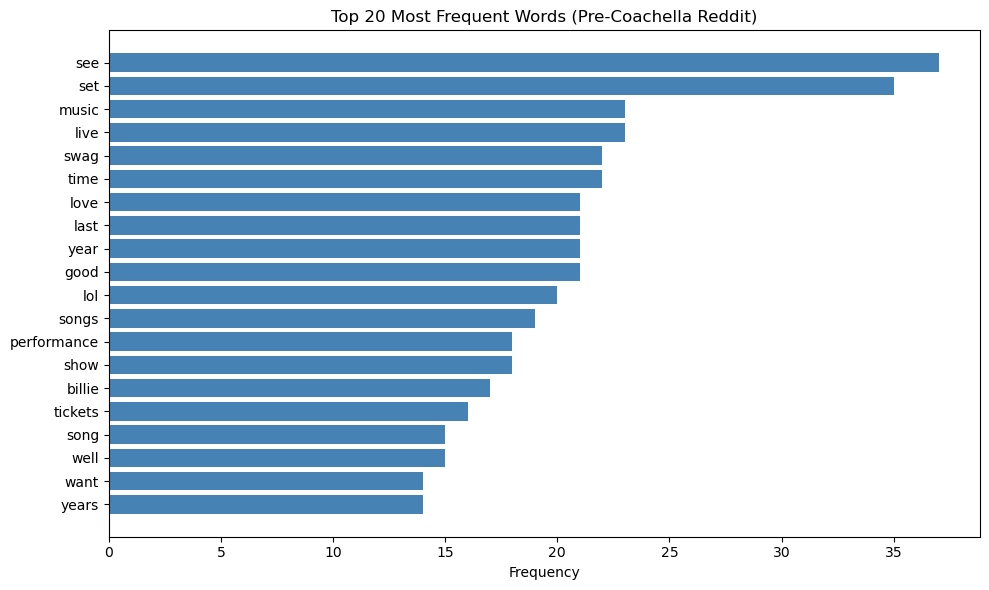

✓ Saved top_words.png


In [7]:
# ─────────────────────────────────────────
# 2. TOP 20 WORDS
# ─────────────────────────────────────────
word_freq = Counter(all_tokens)
top_words = word_freq.most_common(20)

print("\n=== TOP 20 WORDS ===")
for word, count in top_words:
    print(f"{word}: {count}")

# Plot
words, counts = zip(*top_words)
plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1], color='steelblue')
plt.title('Top 20 Most Frequent Words (Pre-Coachella Reddit)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()
print("✓ Saved top_words.png")


=== TOP 20 BIGRAMS ===
billie eilish: 6
last minute: 6
set list: 5
private show: 5
frank ocean: 5
last year: 4
live stream: 4
old songs: 4
swag albums: 4
looking forward: 3
ill pay: 3
sabrina carpenter: 3
full circle: 3
circle moment: 3
past years: 3
cant wait: 3
main stage: 3
every year: 3
makes sense: 3
artist guest: 3


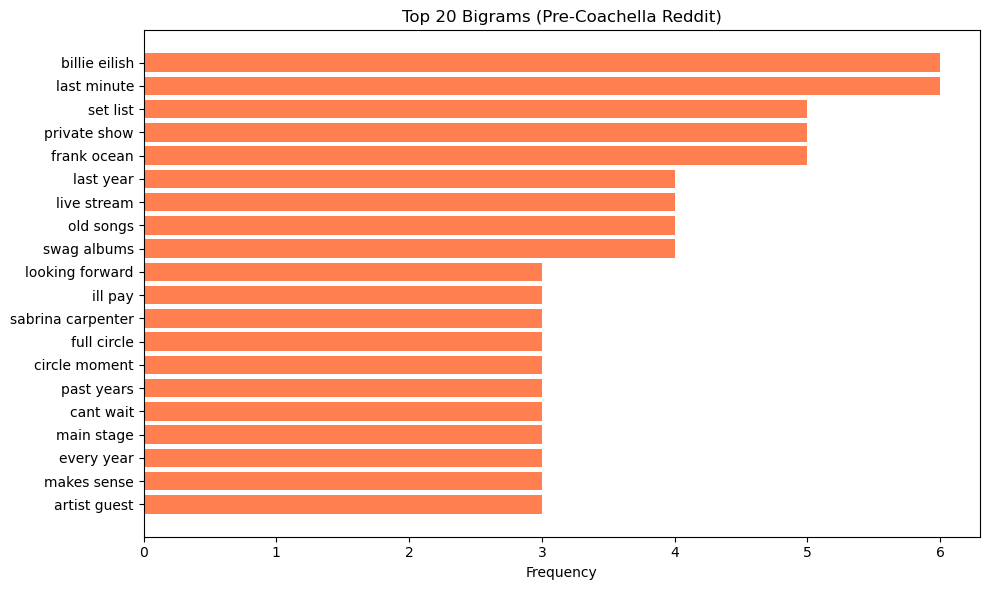

✓ Saved top_bigrams.png


In [8]:

# ─────────────────────────────────────────
# 3. TOP 20 BIGRAMS
# ─────────────────────────────────────────
bigram_list = []
for tokens in df['tokens']:
    bigram_list.extend(list(ngrams(tokens, 2)))

bigram_freq = Counter(bigram_list)
top_bigrams = bigram_freq.most_common(20)

print("\n=== TOP 20 BIGRAMS ===")
for bigram, count in top_bigrams:
    print(f"{' '.join(bigram)}: {count}")

# Plot
bigram_labels = [' '.join(b) for b, _ in top_bigrams]
bigram_counts = [c for _, c in top_bigrams]

plt.figure(figsize=(10, 6))
plt.barh(bigram_labels[::-1], bigram_counts[::-1], color='coral')
plt.title('Top 20 Bigrams (Pre-Coachella Reddit)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('top_bigrams.png', dpi=150)
plt.show()
print("✓ Saved top_bigrams.png")

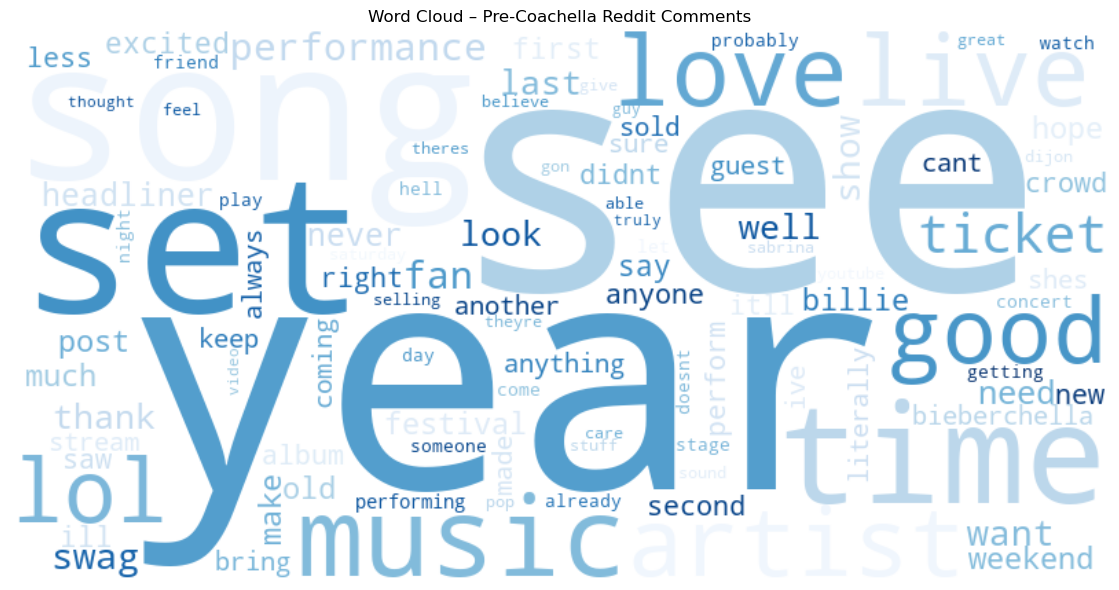

✓ Saved wordcloud.png


In [9]:
# ─────────────────────────────────────────
# 4. WORD CLOUD
# ─────────────────────────────────────────
text_for_cloud = ' '.join(all_tokens)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Blues',
    max_words=100
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – Pre-Coachella Reddit Comments')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()
print("✓ Saved wordcloud.png")

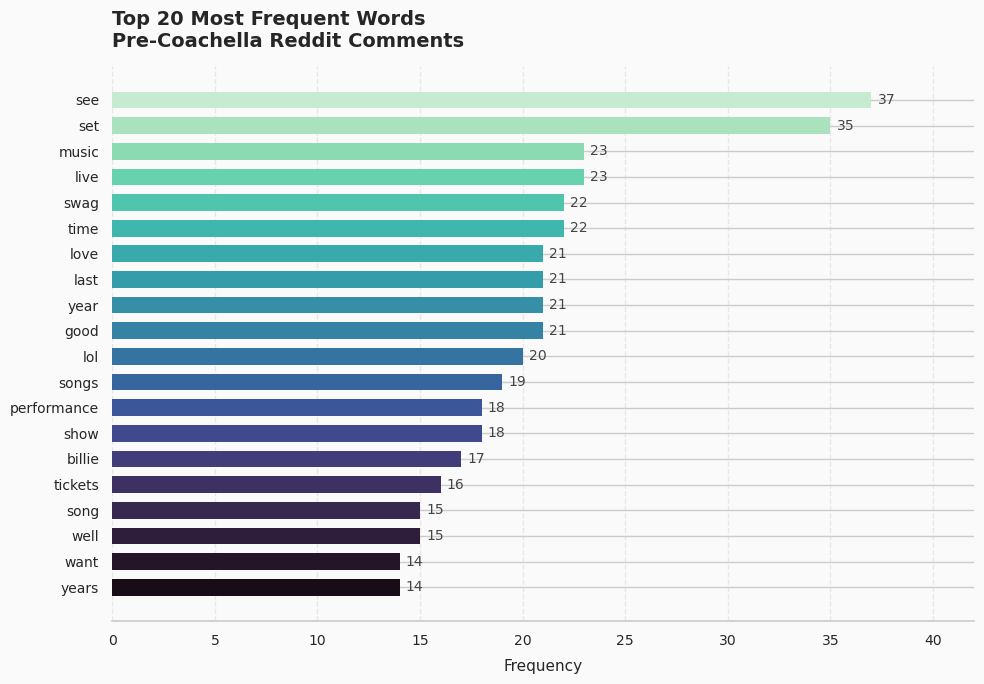

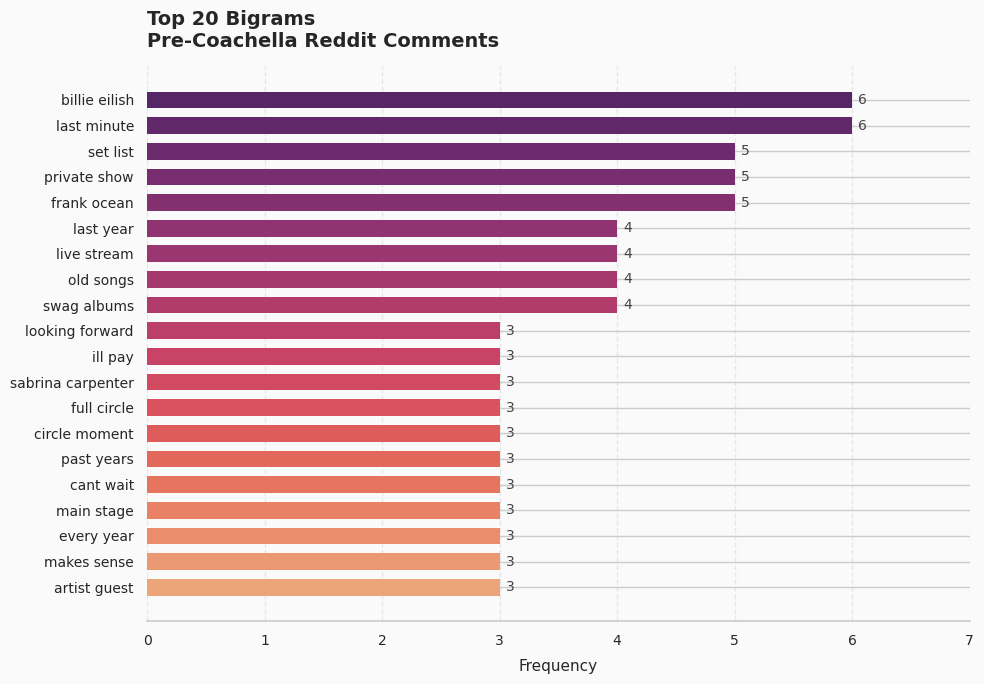

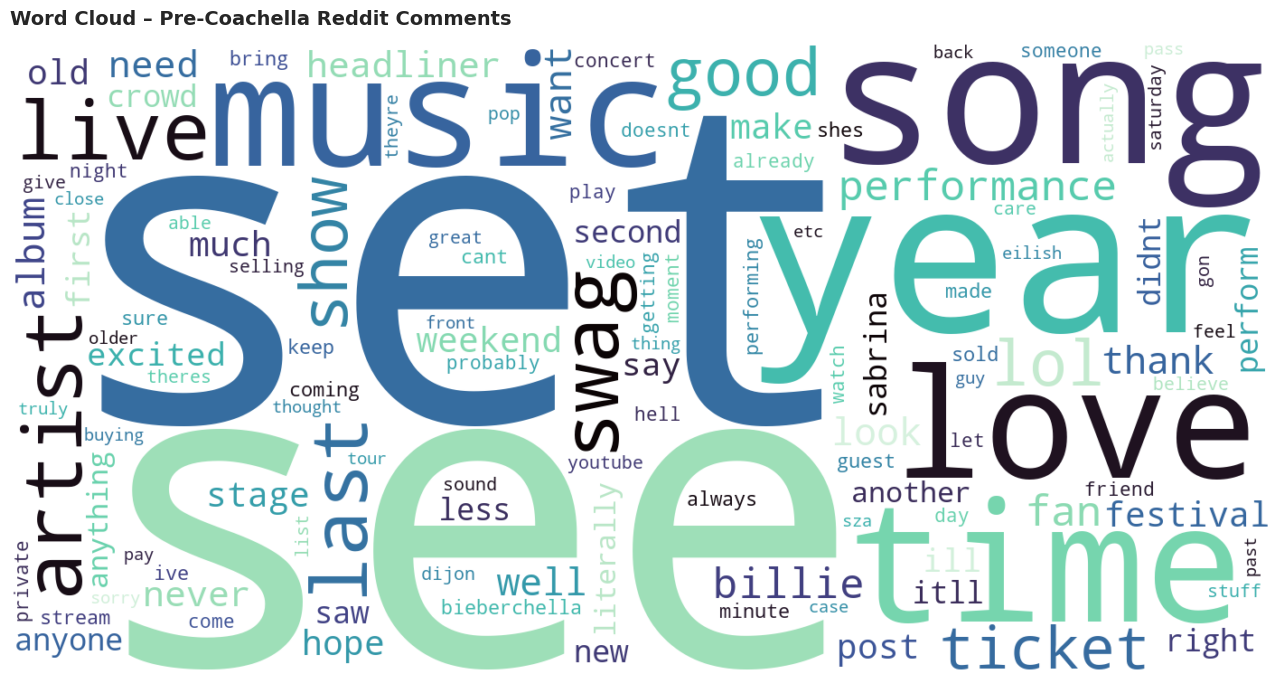

In [11]:
import seaborn as sns
import ast
import matplotlib.ticker as ticker

# ─────────────────────────────────────────
# STYLE SETUP FOR BETTER CHARTS
# ─────────────────────────────────────────
sns.set_theme(style="whitegrid", font="DejaVu Sans")
PALETTE_WORDS   = sns.color_palette("mako", 20)
PALETTE_BIGRAMS = sns.color_palette("flare", 20)
BG = "#FAFAFA"
TITLE_SIZE, LABEL_SIZE, TICK_SIZE = 14, 11, 10

# ─────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────
df = pd.read_csv('reddit_preprocessed.csv')
df['tokens'] = df['tokens'].apply(ast.literal_eval)
all_tokens = [t for tokens in df['tokens'] for t in tokens]

# ─────────────────────────────────────────
# TOP 20 WORDS
# ─────────────────────────────────────────
word_freq = Counter(all_tokens)
top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(list(words)[::-1], list(counts)[::-1], color=PALETTE_WORDS, edgecolor="none", height=0.65)
for bar, val in zip(bars, list(counts)[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=TICK_SIZE, color='#444444')
ax.set_title('Top 20 Most Frequent Words\nPre-Coachella Reddit Comments',
             fontsize=TITLE_SIZE, fontweight='bold', pad=14, loc='left')
ax.set_xlabel('Frequency', fontsize=LABEL_SIZE, labelpad=8)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.tick_params(axis='both', labelsize=TICK_SIZE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, max(counts) + 5)
plt.tight_layout()
plt.savefig('top_words.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

# ─────────────────────────────────────────
# TOP 20 BIGRAMS
# ─────────────────────────────────────────
bigram_list = []
for tokens in df['tokens']:
    bigram_list.extend(list(ngrams(tokens, 2)))
bigram_freq = Counter(bigram_list)
top_bigrams = bigram_freq.most_common(20)
bigram_labels = [' '.join(b) for b, _ in top_bigrams]
bigram_counts = [c for _, c in top_bigrams]

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(bigram_labels[::-1], bigram_counts[::-1], color=PALETTE_BIGRAMS, edgecolor="none", height=0.65)
for bar, val in zip(bars, bigram_counts[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=TICK_SIZE, color='#444444')
ax.set_title('Top 20 Bigrams\nPre-Coachella Reddit Comments',
             fontsize=TITLE_SIZE, fontweight='bold', pad=14, loc='left')
ax.set_xlabel('Frequency', fontsize=LABEL_SIZE, labelpad=8)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.tick_params(axis='both', labelsize=TICK_SIZE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, max(bigram_counts) + 1)
plt.tight_layout()
plt.savefig('top_bigrams.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

# ─────────────────────────────────────────
# WORD CLOUD
# ─────────────────────────────────────────
text_for_cloud = ' '.join(all_tokens)
wordcloud = WordCloud(
    width=1400, height=700, background_color='white',
    colormap='mako', max_words=120, collocations=False,
    prefer_horizontal=0.85, margin=8
).generate(text_for_cloud)

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud – Pre-Coachella Reddit Comments',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12, loc='left')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

In [12]:
import pandas as pd
from collections import Counter
from itertools import combinations
import ast
import matplotlib.patches as mpatches
import numpy as np

# ─────────────────────────────────────────
# 1. LOAD
# ─────────────────────────────────────────
df = pd.read_csv('reddit_preprocessed.csv')
df['tokens'] = df['tokens'].apply(ast.literal_eval)

# ─────────────────────────────────────────
# 2. BUILD CO-OCCURRENCE MATRIX
# Use top N words only to keep the diagram readable
# ─────────────────────────────────────────
all_tokens = [t for tokens in df['tokens'] for t in tokens]
word_freq = Counter(all_tokens)
TOP_N = 30  # number of words on the circle
top_words = [w for w, _ in word_freq.most_common(TOP_N)]

# Count co-occurrences within each comment
cooc = Counter()
for tokens in df['tokens']:
    # Only keep top words
    filtered = [t for t in tokens if t in top_words]
    # All pairs in this comment
    for pair in combinations(set(filtered), 2):
        pair = tuple(sorted(pair))
        cooc[pair] += 1

# Filter weak connections
MIN_COOC = 2
cooc = {pair: count for pair, count in cooc.items() if count >= MIN_COOC}

print(f"Top {TOP_N} words, {len(cooc)} co-occurrence pairs (min {MIN_COOC})")

Top 30 words, 153 co-occurrence pairs (min 2)


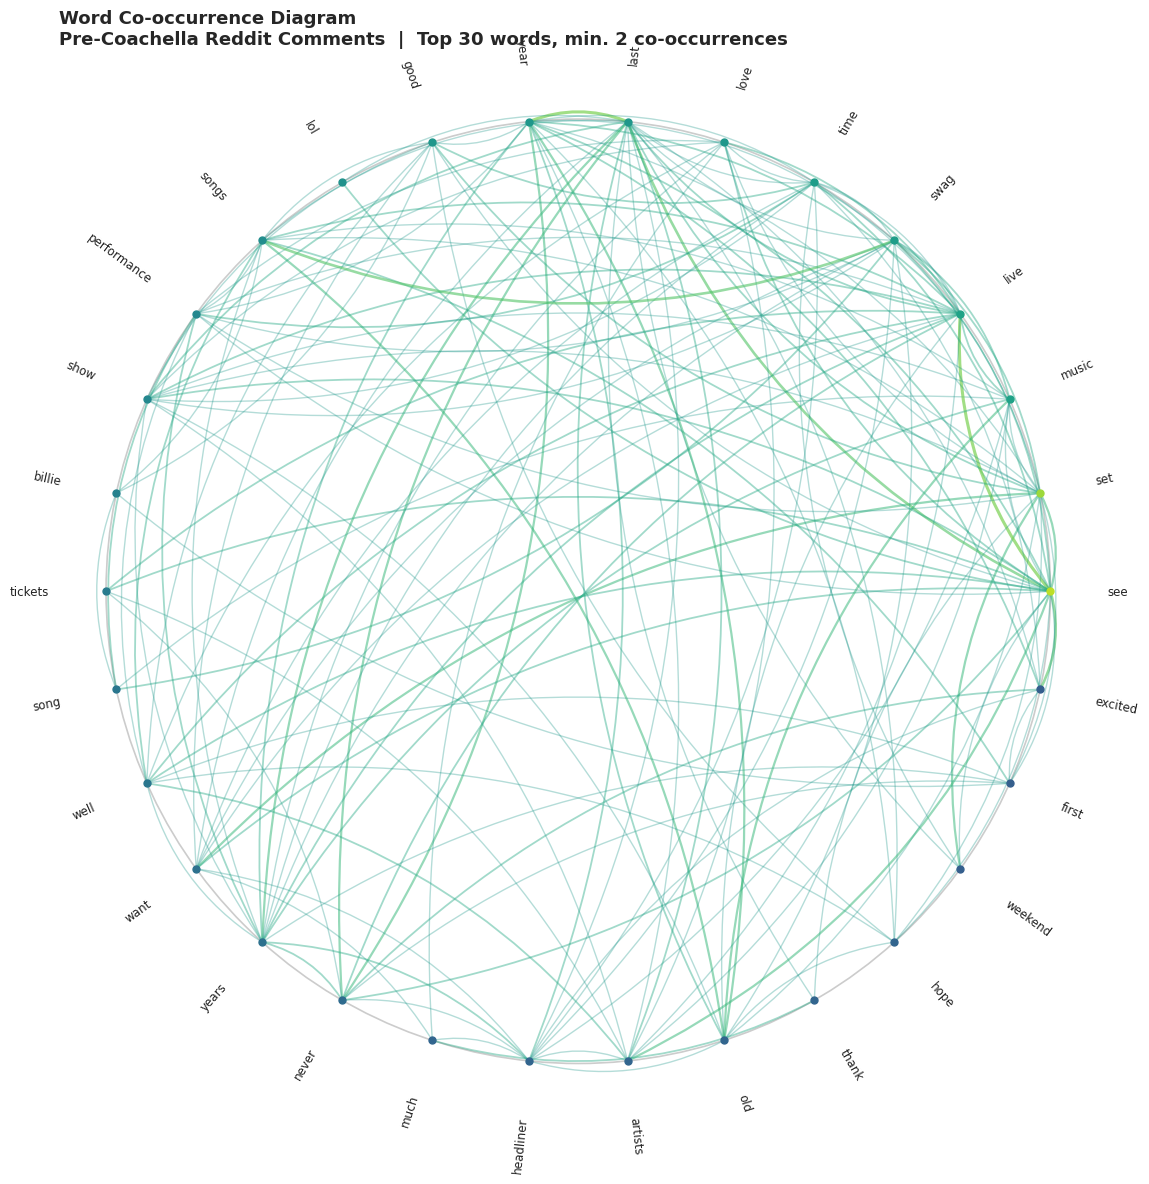

✓ Saved cooccurrence_chord.png


In [14]:

# ─────────────────────────────────────────
# 3. DRAW CHORD DIAGRAM
# ─────────────────────────────────────────
words = top_words
n = len(words)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
word_to_angle = {w: a for w, a in zip(words, angles)}

fig, ax = plt.subplots(figsize=(12, 12), facecolor='white')
ax.set_facecolor('white')
ax.set_aspect('equal')
ax.axis('off')

RADIUS = 1.0
LABEL_RADIUS = 1.12

# Normalize co-occurrence counts for alpha/linewidth
max_cooc = max(cooc.values()) if cooc else 1

# Color by frequency bucket
freq_values = [word_freq[w] for w in words]
freq_norm = [(f - min(freq_values)) / (max(freq_values) - min(freq_values) + 1e-9)
             for f in freq_values]
cmap = plt.cm.viridis

# Draw arcs between co-occurring words
for (w1, w2), count in cooc.items():
    a1 = word_to_angle[w1]
    a2 = word_to_angle[w2]
    x1, y1 = RADIUS * np.cos(a1), RADIUS * np.sin(a1)
    x2, y2 = RADIUS * np.cos(a2), RADIUS * np.sin(a2)

    alpha = 0.15 + 0.55 * (count / max_cooc)
    lw    = 0.4  + 1.8  * (count / max_cooc)
    color = cmap(0.4 + 0.4 * (count / max_cooc))

    # Bezier curve through center
    ax.annotate("",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-",
            color=color,
            alpha=alpha,
            lw=lw,
            connectionstyle="arc3,rad=0.2"
        )
    )

# Draw word labels and dots on the circle
for word, angle in zip(words, angles):
    x = LABEL_RADIUS * np.cos(angle)
    y = LABEL_RADIUS * np.sin(angle)

    # Rotate label to follow circle
    deg = np.degrees(angle)
    if 90 < deg <= 270:
        deg_label = deg + 180
        ha = 'right'
    else:
        deg_label = deg
        ha = 'left'

    freq_idx = words.index(word)
    color = cmap(0.3 + 0.6 * freq_norm[freq_idx])

    ax.text(x, y, word, ha=ha, va='center',
            fontsize=8.5, rotation=deg_label,
            rotation_mode='anchor',
            color='#222222', fontweight='normal')

    # Dot on the circle
    dot_x = RADIUS * np.cos(angle)
    dot_y = RADIUS * np.sin(angle)
    ax.plot(dot_x, dot_y, 'o', color=color, markersize=5, zorder=5)

# Outer ring
circle = plt.Circle((0, 0), RADIUS, color='#cccccc', fill=False, linewidth=1.2)
ax.add_patch(circle)

ax.set_title('Word Co-occurrence Diagram\nPre-Coachella Reddit Comments  |  Top 30 words, min. 2 co-occurrences',
             fontsize=13, fontweight='bold', pad=20, loc='left')

plt.tight_layout()
plt.savefig('cooccurrence_chord.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved cooccurrence_chord.png")

Top 20 words, 7 co-occurrence pairs (min 4)


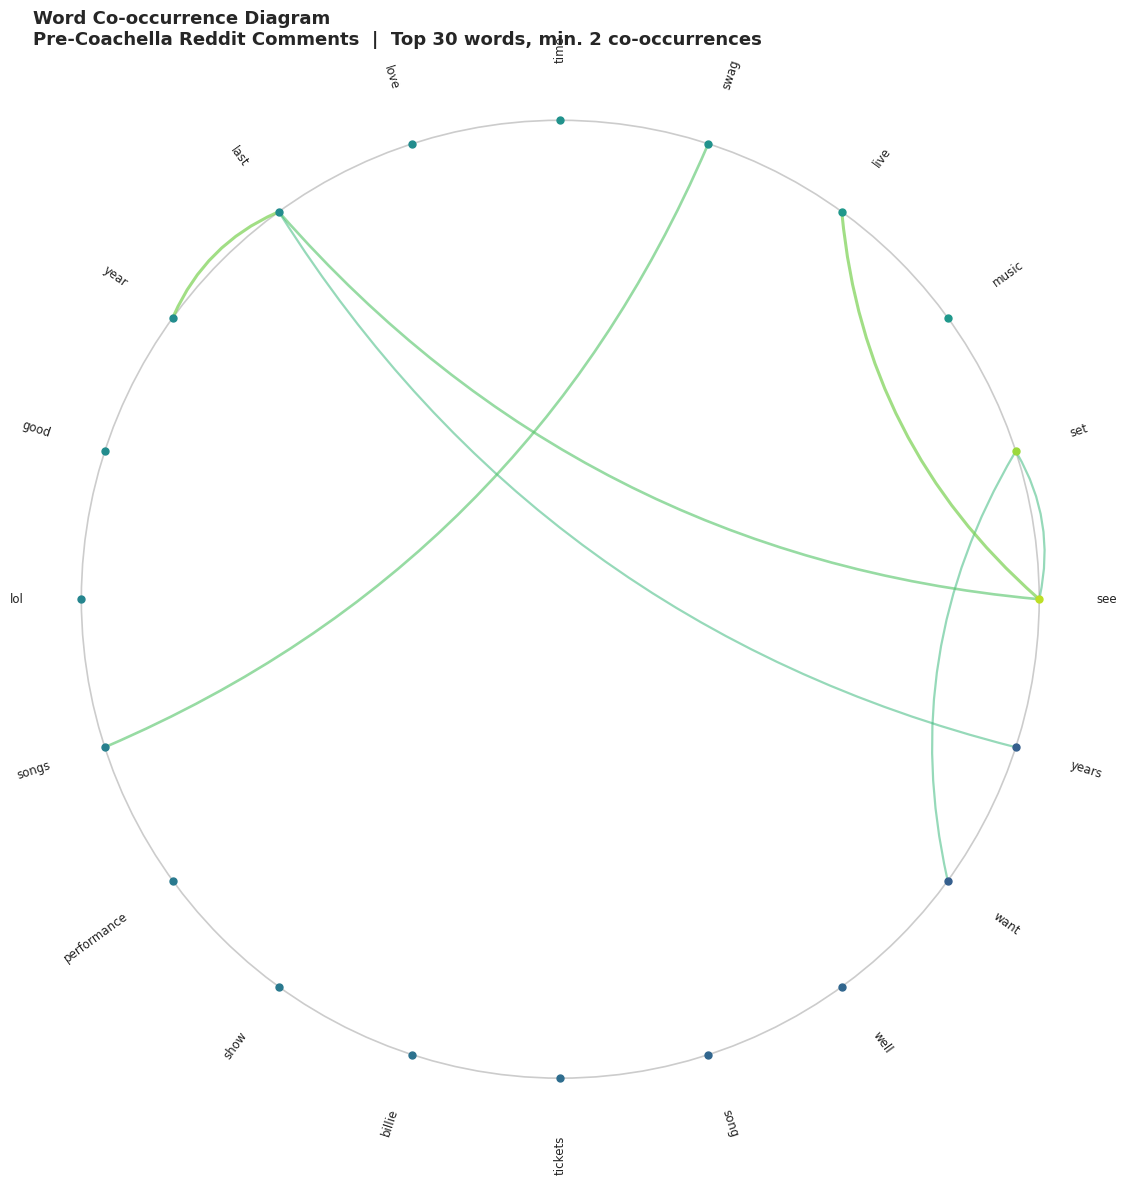

✓ Saved cooccurrence_chord.png


In [15]:
# ─────────────────────────────────────────
# SECOND TRY: BUILD CO-OCCURRENCE MATRIX
# Use top N words only to keep the diagram readable
# ─────────────────────────────────────────
all_tokens = [t for tokens in df['tokens'] for t in tokens]
word_freq = Counter(all_tokens)
TOP_N = 20  # number of words on the circle
top_words = [w for w, _ in word_freq.most_common(TOP_N)]

# Count co-occurrences within each comment
cooc = Counter()
for tokens in df['tokens']:
    # Only keep top words
    filtered = [t for t in tokens if t in top_words]
    # All pairs in this comment
    for pair in combinations(set(filtered), 2):
        pair = tuple(sorted(pair))
        cooc[pair] += 1

# Filter weak connections
MIN_COOC = 4
cooc = {pair: count for pair, count in cooc.items() if count >= MIN_COOC}

print(f"Top {TOP_N} words, {len(cooc)} co-occurrence pairs (min {MIN_COOC})")

# ─────────────────────────────────────────
# 3. DRAW CHORD DIAGRAM
# ─────────────────────────────────────────
words = top_words
n = len(words)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
word_to_angle = {w: a for w, a in zip(words, angles)}

fig, ax = plt.subplots(figsize=(12, 12), facecolor='white')
ax.set_facecolor('white')
ax.set_aspect('equal')
ax.axis('off')

RADIUS = 1.0
LABEL_RADIUS = 1.12

# Normalize co-occurrence counts for alpha/linewidth
max_cooc = max(cooc.values()) if cooc else 1

# Color by frequency bucket
freq_values = [word_freq[w] for w in words]
freq_norm = [(f - min(freq_values)) / (max(freq_values) - min(freq_values) + 1e-9)
             for f in freq_values]
cmap = plt.cm.viridis

# Draw arcs between co-occurring words
for (w1, w2), count in cooc.items():
    a1 = word_to_angle[w1]
    a2 = word_to_angle[w2]
    x1, y1 = RADIUS * np.cos(a1), RADIUS * np.sin(a1)
    x2, y2 = RADIUS * np.cos(a2), RADIUS * np.sin(a2)

    alpha = 0.15 + 0.55 * (count / max_cooc)
    lw    = 0.4  + 1.8  * (count / max_cooc)
    color = cmap(0.4 + 0.4 * (count / max_cooc))

    # Bezier curve through center
    ax.annotate("",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-",
            color=color,
            alpha=alpha,
            lw=lw,
            connectionstyle="arc3,rad=0.2"
        )
    )

# Draw word labels and dots on the circle
for word, angle in zip(words, angles):
    x = LABEL_RADIUS * np.cos(angle)
    y = LABEL_RADIUS * np.sin(angle)

    # Rotate label to follow circle
    deg = np.degrees(angle)
    if 90 < deg <= 270:
        deg_label = deg + 180
        ha = 'right'
    else:
        deg_label = deg
        ha = 'left'

    freq_idx = words.index(word)
    color = cmap(0.3 + 0.6 * freq_norm[freq_idx])

    ax.text(x, y, word, ha=ha, va='center',
            fontsize=8.5, rotation=deg_label,
            rotation_mode='anchor',
            color='#222222', fontweight='normal')

    # Dot on the circle
    dot_x = RADIUS * np.cos(angle)
    dot_y = RADIUS * np.sin(angle)
    ax.plot(dot_x, dot_y, 'o', color=color, markersize=5, zorder=5)

# Outer ring
circle = plt.Circle((0, 0), RADIUS, color='#cccccc', fill=False, linewidth=1.2)
ax.add_patch(circle)

ax.set_title('Word Co-occurrence Diagram\nPre-Coachella Reddit Comments  |  Top 30 words, min. 2 co-occurrences',
             fontsize=13, fontweight='bold', pad=20, loc='left')

plt.tight_layout()
plt.savefig('cooccurrence_chord.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved cooccurrence_chord.png")

In [16]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

# ─────────────────────────────────────────
# STYLE SETUP
# ─────────────────────────────────────────
sns.set_theme(style="whitegrid", font="DejaVu Sans")
BG = "#FAFAFA"
PALETTE = {"positive": "#2a9d8f", "neutral": "#e9c46a", "negative": "#e76f51"}
TITLE_SIZE, LABEL_SIZE, TICK_SIZE = 14, 11, 10

# ─────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────
df = pd.read_csv('reddit_preprocessed.csv')
df = df.dropna(subset=['comment_text'])

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/alaraakcasiz/nltk_data...


In [17]:
# ─────────────────────────────────────────
# 2. RUN VADER
# ─────────────────────────────────────────
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(str(text))
    if score['compound'] >= 0.05:
        return 'positive'
    elif score['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_compound'] = df['comment_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df['vader_sentiment'] = df['comment_text'].apply(get_sentiment)

print("=== VADER SENTIMENT DISTRIBUTION ===")
print(df['vader_sentiment'].value_counts())
print(f"\nMean compound score: {df['vader_compound'].mean():.3f}")

=== VADER SENTIMENT DISTRIBUTION ===
vader_sentiment
positive    181
neutral     119
negative     50
Name: count, dtype: int64

Mean compound score: 0.239


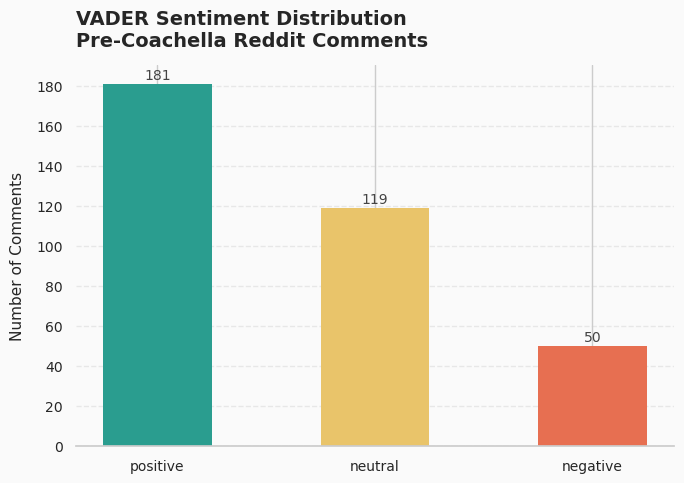

✓ Saved sentiment_distribution.png


In [18]:
# ─────────────────────────────────────────
# 3. OVERALL DISTRIBUTION — BAR CHART
# ─────────────────────────────────────────
sentiment_counts = df['vader_sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])

fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=[PALETTE[s] for s in sentiment_counts.index],
    edgecolor='none',
    width=0.5
)

for bar, val in zip(bars, sentiment_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=TICK_SIZE, color='#444444')

ax.set_title('VADER Sentiment Distribution\nPre-Coachella Reddit Comments',
             fontsize=TITLE_SIZE, fontweight='bold', pad=14, loc='left')
ax.set_ylabel('Number of Comments', fontsize=LABEL_SIZE, labelpad=8)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.tick_params(axis='both', labelsize=TICK_SIZE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Saved sentiment_distribution.png")

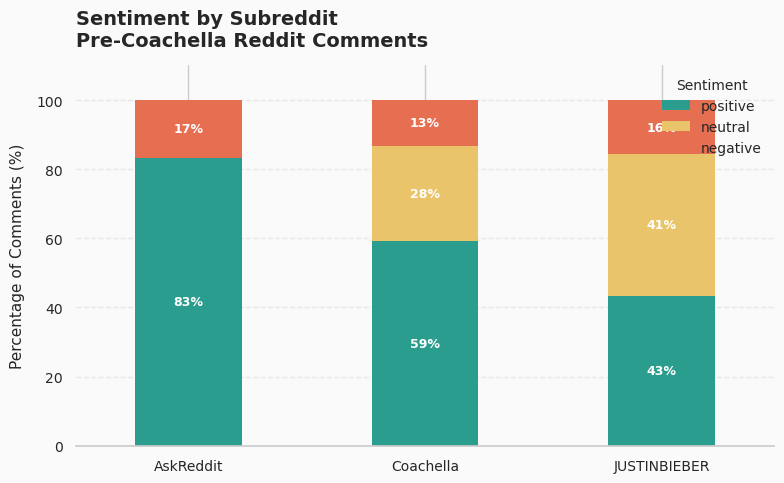

✓ Saved sentiment_by_subreddit.png


In [21]:
# ─────────────────────────────────────────
# 4. SENTIMENT BY SUBREDDIT — STACKED BAR
# ─────────────────────────────────────────
if 'subreddit' in df.columns:
    sub_sentiment = (
        df.groupby(['subreddit', 'vader_sentiment'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=['positive', 'neutral', 'negative'])
    )
    sub_sentiment = sub_sentiment[sub_sentiment.sum(axis=1) >= 5]

    # Normalize to percentages for fair comparison
    sub_pct = sub_sentiment.div(sub_sentiment.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    ax.set_facecolor(BG)

    sub_pct.plot(
        kind='bar',
        stacked=True,
        color=[PALETTE[s] for s in sub_pct.columns],
        edgecolor='none',
        ax=ax,
        width=0.45
    )

    # Add percentage labels inside bars
    for i, (idx, row) in enumerate(sub_pct.iterrows()):
        cumulative = 0
        for sentiment, val in row.items():
            if val > 5:
                ax.text(i, cumulative + val / 2, f'{val:.0f}%',
                        ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
            cumulative += val

    ax.set_title('Sentiment by Subreddit\nPre-Coachella Reddit Comments',
                 fontsize=TITLE_SIZE, fontweight='bold', pad=14, loc='left')
    ax.set_ylabel('Percentage of Comments (%)', fontsize=LABEL_SIZE, labelpad=8)
    ax.set_xlabel('')
    ax.set_ylim(0, 110)
    ax.tick_params(axis='x', labelsize=TICK_SIZE, rotation=0)
    ax.tick_params(axis='y', labelsize=TICK_SIZE)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(title='Sentiment', fontsize=TICK_SIZE, title_fontsize=TICK_SIZE,
              frameon=False, loc='upper right')

    plt.tight_layout()
    plt.savefig('sentiment_by_subreddit.png', dpi=180, bbox_inches='tight', facecolor=BG)
    plt.show()
    print("✓ Saved sentiment_by_subreddit.png")

In [22]:
# ─────────────────────────────────────────
# 5. EXAMPLE COMMENTS PER CATEGORY
# ─────────────────────────────────────────
print("\n=== EXAMPLE COMMENTS ===")
for sentiment in ['positive', 'neutral', 'negative']:
    print(f"\n-- {sentiment.upper()} --")
    examples = df[df['vader_sentiment'] == sentiment]['comment_text'].head(3)
    for i, ex in enumerate(examples, 1):
        print(f"{i}. {ex[:200]}")


=== EXAMPLE COMMENTS ===

-- POSITIVE --
1. **Selling**: 2x VIP wristbands (SUNDAY ONLY) + 2x Shuttle passes
 

 **Weekend**: 1
 

 **Price**: Open to offers, send a PM
 

 **Additional Information**: Sunday only, and have to be able to meet af
2. Justin Bieber with Yummy from Chnages (2020). Radio material unfortunately he should’ve released a different song. He had so much hype and buzz. Could’ve played it cool by saying the “real” single wou
3. Wouldn’t be surprised if she does another DoLab set

-- NEUTRAL --
1. yess it must be billie it will be SOO iconic
2. I disagree. But who gives a shit? If you’re on the grounds this weekend, have a great time
3. def thought this was about Justin Bieber 😭😭

-- NEGATIVE --
1. Literally how is this copyrighted it’s a fucking video of my parents’ backyard with music in the background??? Okay I guess Justin Bieber didn’t want to have his set spoiled BUT it’s his fault for bla
2. i’m so scared that the live stream will break 😭
3. Coachella failed 

In [23]:
# ─────────────────────────────────────────
# 6. SAVE WITH VADER COLUMNS
# ─────────────────────────────────────────
df.to_csv('reddit_sentiment.csv', index=False)
print("\n✓ Saved reddit_sentiment.csv")


✓ Saved reddit_sentiment.csv


In [25]:
!pip install rake-nltk
from rake_nltk import Rake
from collections import defaultdict

# ─────────────────────────────────────────
# STYLE SETUP
# ─────────────────────────────────────────
sns.set_theme(style="whitegrid", font="DejaVu Sans")
BG = "#FAFAFA"
TITLE_SIZE, LABEL_SIZE, TICK_SIZE = 14, 11, 10

# ─────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────
df = pd.read_csv('reddit_sentiment.csv')
df = df.dropna(subset=['comment_text'])
print(f"Total comments: {len(df)}")

Total comments: 350


In [26]:
# ─────────────────────────────────────────
# 2. RUN RAKE
# ─────────────────────────────────────────
# RAKE works on raw text, not cleaned
r = Rake(
    min_length=1,  # minimum words in a phrase
    max_length=4   # maximum words in a phrase
)

all_phrases = []

for text in df['comment_text']:
    r.extract_keywords_from_text(str(text))
    phrases = r.get_ranked_phrases_with_scores()
    # Keep phrases with score >= 4 (filters low-signal single words)
    for score, phrase in phrases:
        if score >= 4:
            all_phrases.append((score, phrase.lower().strip()))

print(f"Total phrases extracted: {len(all_phrases)}")

Total phrases extracted: 1035


In [28]:
custom_stopwords = [
    'gif', 'giphy', 'https', 'preview', 'www', 'reddit', 'com',
    'jpeg', 'png', 'webp', 'format', 'width', 'auto', 'redd', 'it'
]

r = Rake(
    min_length=1,
    max_length=4,
    stopwords=custom_stopwords
)
artifacts = ['giphy', 'https', 'preview', 'www', 'jpeg', 'png', 'webp', 'redd']

all_phrases = []
for text in df['comment_text']:
    r.extract_keywords_from_text(str(text))
    phrases = r.get_ranked_phrases_with_scores()
    for score, phrase in phrases:
        if score >= 4:
            # Skip artifact phrases
            if any(a in phrase.lower() for a in artifacts):
                continue
            all_phrases.append((score, phrase.lower().strip()))
# ─────────────────────────────────────────
# 3. AGGREGATE AND RANK
# ─────────────────────────────────────────
# Count phrase frequency and sum scores
phrase_freq  = defaultdict(int)
phrase_score = defaultdict(float)

for score, phrase in all_phrases:
    phrase_freq[phrase]  += 1
    phrase_score[phrase] += score

# Rank by frequency, show top 30
top_phrases = sorted(phrase_freq.items(), key=lambda x: x[1], reverse=True)[:30]

print("\n=== TOP 30 RAKE PHRASES ===")
for phrase, freq in top_phrases:
    print(f"  {phrase} (freq: {freq}, score: {phrase_score[phrase]:.1f})")



=== TOP 30 RAKE PHRASES ===
  :// youtu (freq: 4, score: 16.0)
  thank you (freq: 3, score: 12.0)
  justin bieber (freq: 3, score: 12.0)
  but i (freq: 2, score: 8.5)
  i don (freq: 2, score: 8.0)
  sunday only (freq: 1, score: 4.0)
  could ’ ve played (freq: 1, score: 16.0)
  bieber fever never dies (freq: 1, score: 16.0)
  to go no 1 (freq: 1, score: 15.0)
  to swag 1 (freq: 1, score: 10.0)
  2020 ). (freq: 1, score: 4.0)
  love you !!! (freq: 1, score: 9.0)
  i got you (freq: 1, score: 9.0)
  in honor of bieberchella (freq: 1, score: 16.0)
  will be soo iconic (freq: 1, score: 15.5)
  must be billie (freq: 1, score: 9.5)
  would be so iconic (freq: 1, score: 16.0)
  ive found my people (freq: 1, score: 16.0)
  finnallyyy someone !!! (freq: 1, score: 9.0)
  like literally (freq: 1, score: 4.0)
  have a great time (freq: 1, score: 16.0)
  i disagree (freq: 1, score: 4.0)
  justin bieber 100 percent (freq: 1, score: 16.0)
  from u lol (freq: 1, score: 9.0)
  or gaga (freq: 1, score: 4

In [34]:
from openai import AzureOpenAI
from tqdm import tqdm
import time

# ─────────────────────────────────────────
# 1. AZURE OPENAI SETUP
# Copy your API key from:
# https://aisma2026.openai.azure.com/ → Home → API key 1
# ─────────────────────────────────────────
api_key = "G0OuQ1qJgAwUqkvqzQ86vw7MlOMHvClofmWIQUViha9a3TNFhk63JQQJ99CCACYeBjFXJ3w3AAABACOGioqx"

client = AzureOpenAI(
    azure_endpoint="https://aisma2026.openai.azure.com/",
    api_key=api_key,
    api_version="2025-01-01-preview"
)

# ─────────────────────────────────────────
# 2. LOAD DATA
# ─────────────────────────────────────────
df = pd.read_csv('reddit_sentiment.csv')
df = df.dropna(subset=['comment_text'])

sample = df.copy()
print(f"Running LLM analysis on {len(sample)} comments")

Running LLM analysis on 350 comments


In [35]:
# ─────────────────────────────────────────
# 3. SENTIMENT ANALYSIS WITH GPT
# ─────────────────────────────────────────
def analyze_sentiment(comment, model="gpt-5.4-mini"):
    retries = 3
    while retries > 0:
        messages = [
            {"role": "system", "content": "You are an AI language model trained to analyze sentiment of social media comments."},
            {"role": "user", "content": f"Analyze the following Reddit comment about Justin Bieber's Coachella 2026 performance and determine if the sentiment is positive, negative or neutral. Return only a single word, either POSITIVE, NEGATIVE or NEUTRAL:\n\n{comment}"}
        ]
        try:
            completion = client.chat.completions.create(
                model=model,
                messages=messages,
                max_completion_tokens=10,
                frequency_penalty=0,
                presence_penalty=0,
                stop=None
            )
            response = completion.choices[0].message.content.strip().upper()
            if response in ["POSITIVE", "NEGATIVE", "NEUTRAL"]:
                return response
            else:
                retries -= 1
                time.sleep(1)
        except Exception as e:
            print(f"Error: {e}")
            retries -= 1
            time.sleep(2)
    return "NEUTRAL"

In [36]:

# ─────────────────────────────────────────
# 4. NARRATIVE THEME CLASSIFICATION
# ─────────────────────────────────────────
def classify_theme(comment, model="gpt-5.4-mini"):
    retries = 3
    while retries > 0:
        messages = [
            {"role": "system", "content": "You are an AI assistant that classifies Reddit comments into thematic categories."},
            {"role": "user", "content": f"""Classify the following Reddit comment about Justin Bieber's Coachella 2026 into ONE of these themes:
- NOSTALGIA: mentions old songs, past performances, his early career, setlist debate
- GUEST_SPECULATION: mentions Billie Eilish, surprise guests, collaborations
- HEALTH_ANXIETY: mentions Frank Ocean, cancellation fears, health concerns
- STAR_POWER: mentions ticket demand, Sabrina Carpenter comparison, crowd size
- LOGISTICS: mentions tickets for sale, Airbnb, livestream, shuttle passes

Return only the theme name (e.g. NOSTALGIA). Comment:

{comment}"""}
        ]
        try:
            completion = client.chat.completions.create(
                model=model,
                messages=messages,
                max_completion_tokens=10,
                frequency_penalty=0,
                presence_penalty=0,
                stop=None
            )
            response = completion.choices[0].message.content.strip().upper()
            valid_themes = ["NOSTALGIA", "GUEST_SPECULATION", "HEALTH_ANXIETY", "STAR_POWER", "LOGISTICS"]
            if response in valid_themes:
                return response
            else:
                retries -= 1
                time.sleep(1)
        except Exception as e:
            print(f"Error: {e}")
            retries -= 1
            time.sleep(2)
    return "OTHER"

# ─────────────────────────────────────────
# 5. RUN ANALYSIS
# ─────────────────────────────────────────
print("\nRunning sentiment analysis...")
sentiments = []
for comment in tqdm(sample['comment_text'], desc="Sentiment"):
    sentiment = analyze_sentiment(comment)
    sentiments.append(sentiment)
    time.sleep(0.5)  # be polite to the API

sample['llm_sentiment'] = sentiments

print("\nRunning theme classification...")
themes = []
for comment in tqdm(sample['comment_text'], desc="Themes"):
    theme = classify_theme(comment)
    themes.append(theme)
    time.sleep(0.5)

sample['llm_theme'] = themes

# ─────────────────────────────────────────
# 6. RESULTS
# ─────────────────────────────────────────
print("\n=== LLM SENTIMENT DISTRIBUTION ===")
print(sample['llm_sentiment'].value_counts())

print("\n=== LLM THEME DISTRIBUTION ===")
print(sample['llm_theme'].value_counts())

print("\n=== VADER vs LLM SENTIMENT COMPARISON ===")
# vader_sentiment is already in the df
comparison = pd.crosstab(
    sample['vader_sentiment'].str.upper(),
    sample['llm_sentiment'],
    rownames=['VADER'],
    colnames=['GPT']
)
print(comparison)



Running sentiment analysis...


Sentiment:  83%|████████████████████████▊     | 290/350 [06:31<01:13,  1.22s/it]

Error: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': True, 'filtered': True}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}
Error: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https:

Sentiment: 100%|██████████████████████████████| 350/350 [07:53<00:00,  1.35s/it]



Running theme classification...


Themes: 100%|█████████████████████████████████| 350/350 [10:14<00:00,  1.76s/it]


=== LLM SENTIMENT DISTRIBUTION ===
llm_sentiment
NEUTRAL     143
POSITIVE    132
NEGATIVE     75
Name: count, dtype: int64

=== LLM THEME DISTRIBUTION ===
llm_theme
NOSTALGIA            130
STAR_POWER            84
LOGISTICS             75
GUEST_SPECULATION     32
OTHER                 17
HEALTH_ANXIETY        12
Name: count, dtype: int64

=== VADER vs LLM SENTIMENT COMPARISON ===
GPT       NEGATIVE  NEUTRAL  POSITIVE
VADER                                
NEGATIVE        27        8        15
NEUTRAL         17       73        29
POSITIVE        31       62        88


In [37]:

# ─────────────────────────────────────────
# 7. SAVE
# ─────────────────────────────────────────
sample.to_csv('reddit_llm_analysis.csv', index=False)
print("\n✓ Saved reddit_llm_analysis.csv")



✓ Saved reddit_llm_analysis.csv


In [38]:
# ═══════════════════════════════════════════════════════════════
# AFTER PERIOD ANALYSIS — April 20 – May 3, 2026
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────
# 1. LOAD AFTER DATA
# ─────────────────────────────────────────
df_after = pd.read_csv('reddit_after_with_dates.csv')

text_col = 'Full Text'
df_after = df_after.rename(columns={text_col: 'comment_text'})
df_after = df_after.dropna(subset=['comment_text'])
df_after = df_after[df_after['comment_text'].str.strip() != '']

# Exclude April 19 — Weekend 2 day-of comments, not post-event
df_after = df_after[df_after['post_date'] >= '2026-04-20']

print(f"Total after comments: {len(df_after)}")

# ─────────────────────────────────────────
# 2. PREPROCESSING
# ─────────────────────────────────────────
df_after['tokens'] = df_after['comment_text'].apply(preprocess)
df_after['cleaned_text'] = df_after['tokens'].apply(lambda tokens: ' '.join(tokens))

if 'Url' in df_after.columns:
    subreddits_after = df_after['Url'].str.extract(r'reddit\.com/r/(\w+)/')
    df_after['subreddit'] = subreddits_after[0]

df_after.to_csv('reddit_preprocessed_after.csv', index=False)
print("✓ Saved reddit_preprocessed_after.csv")

print(f"\nSentiment distribution (Brandwatch):")
print(df_after['Sentiment'].value_counts())
if 'Emotion' in df_after.columns:
    print(f"\nEmotion distribution:")
    print(df_after['Emotion'].value_counts())
if 'subreddit' in df_after.columns:
    print(f"\nSubreddit distribution:")
    print(df_after['subreddit'].value_counts())

Total after comments: 846
✓ Saved reddit_preprocessed_after.csv

Sentiment distribution (Brandwatch):
Sentiment
neutral     417
negative    275
positive    154
Name: count, dtype: int64

Emotion distribution:
Emotion
Sadness     226
Joy         161
Anger       123
Disgust      59
Fear         18
Surprise     12
Name: count, dtype: int64

Subreddit distribution:
subreddit
Coachella        402
JUSTINBIEBER     356
AskReddit         29
OutOfTheLoop      21
Music             14
popheads          12
entertainment     11
indieheads         1
Name: count, dtype: int64



Total tokens: 13097
Unique tokens: 3803

=== TOP 20 WORDS (AFTER) ===
  set: 103
  see: 92
  performance: 92
  year: 90
  weekend: 90
  music: 73
  much: 69
  years: 63
  festival: 60
  fans: 60
  time: 58
  live: 57
  stage: 54
  artists: 53
  didnt: 51
  crowd: 49
  first: 46
  lol: 46
  biebers: 45
  full: 45


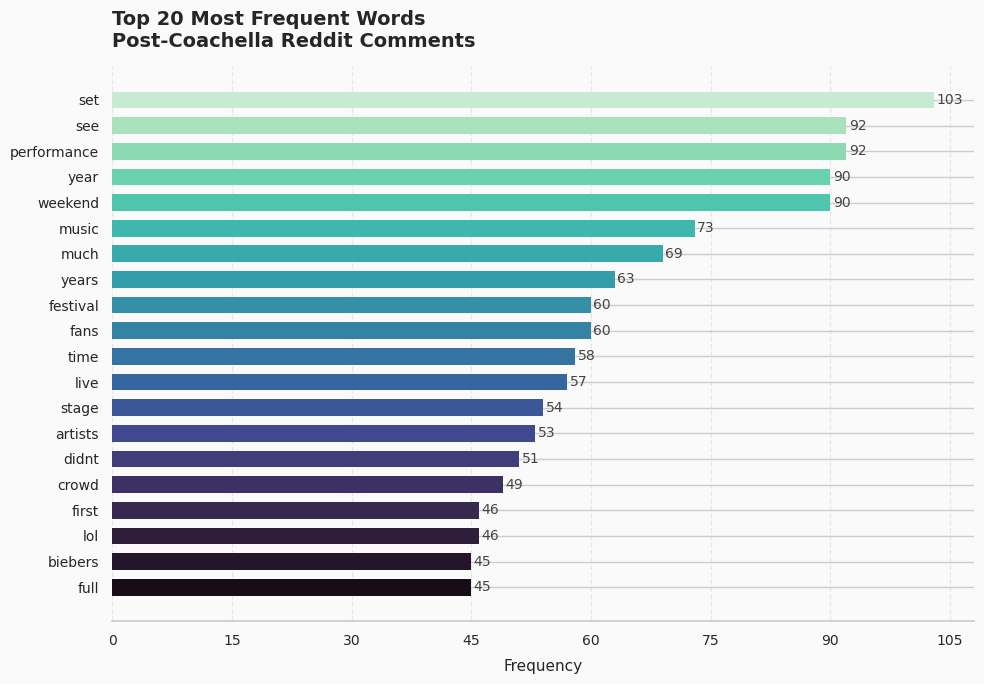

✓ Saved top_words_after.png

=== TOP 20 BIGRAMS (AFTER) ===
  full performance: 24
  main stage: 22
  weekend full: 18
  last year: 15
  biebers set: 14
  ella langley: 12
  next year: 11
  lady gaga: 11
  sabrina carpenter: 11
  biebers performance: 10
  david byrne: 10
  first time: 8
  nine inch: 7
  daft punk: 6
  iggy pop: 6
  pop stars: 6
  olivia rodrigo: 6
  live stream: 6
  monthly listeners: 6
  social media: 6


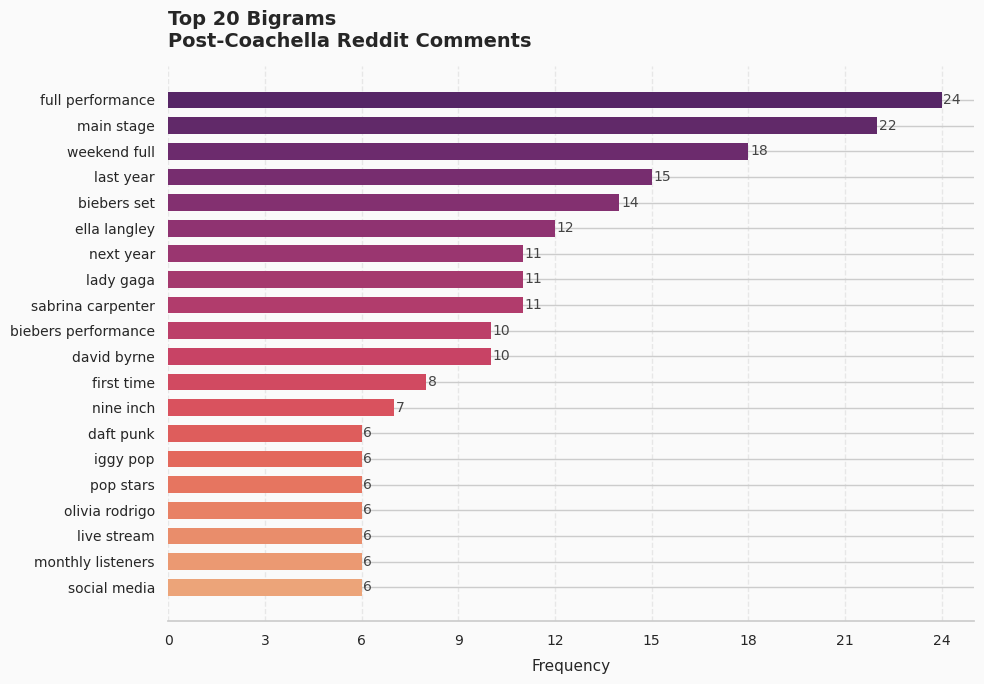

✓ Saved top_bigrams_after.png


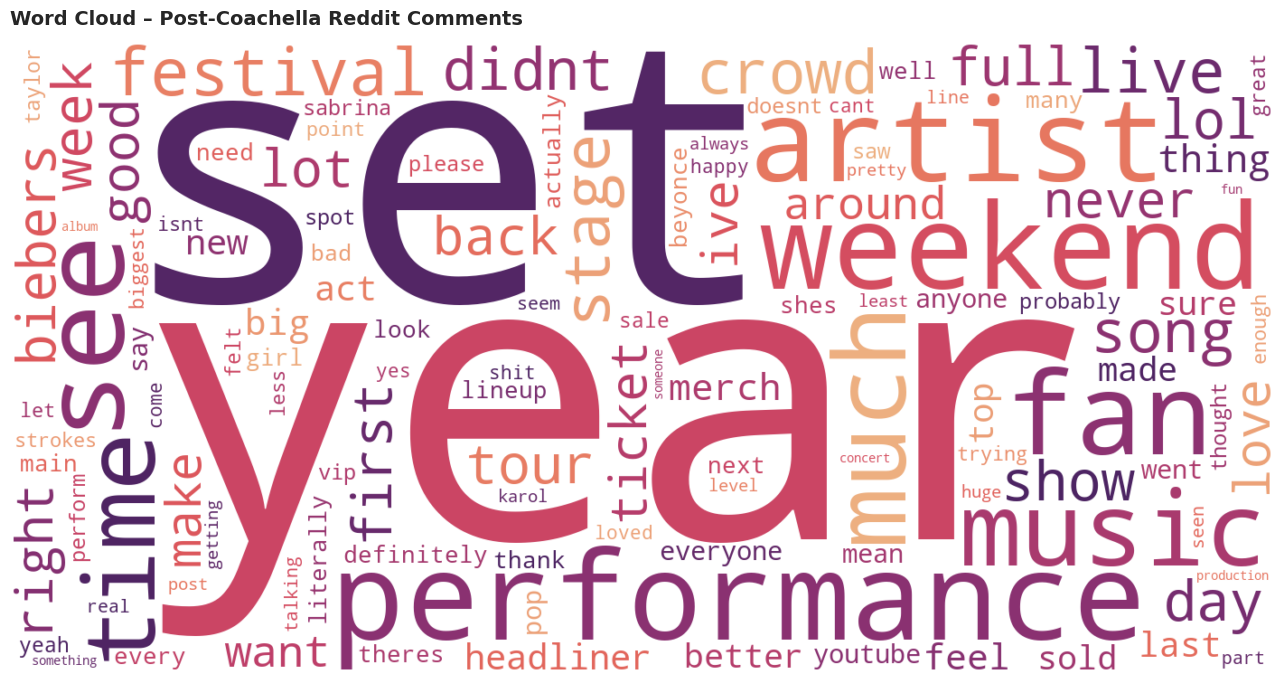

✓ Saved wordcloud_after.png


In [39]:
# ─────────────────────────────────────────
# 3. FREQUENCY ANALYSIS
# ─────────────────────────────────────────
all_tokens_after = [t for tokens in df_after['tokens'] for t in tokens]
print(f"\nTotal tokens: {len(all_tokens_after)}")
print(f"Unique tokens: {len(set(all_tokens_after))}")

word_freq_after = Counter(all_tokens_after)
top_words_after = word_freq_after.most_common(20)

print("\n=== TOP 20 WORDS (AFTER) ===")
for word, count in top_words_after:
    print(f"  {word}: {count}")

words_a, counts_a = zip(*top_words_after)
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(list(words_a)[::-1], list(counts_a)[::-1], color=PALETTE_WORDS, edgecolor="none", height=0.65)
for bar, val in zip(bars, list(counts_a)[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=TICK_SIZE, color='#444444')
ax.set_title('Top 20 Most Frequent Words\nPost-Coachella Reddit Comments',
             fontsize=TITLE_SIZE, fontweight='bold', pad=14, loc='left')
ax.set_xlabel('Frequency', fontsize=LABEL_SIZE, labelpad=8)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.tick_params(axis='both', labelsize=TICK_SIZE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, max(counts_a) + 5)
plt.tight_layout()
plt.savefig('top_words_after.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Saved top_words_after.png")

bigram_list_after = []
for tokens in df_after['tokens']:
    bigram_list_after.extend(list(ngrams(tokens, 2)))
bigram_freq_after = Counter(bigram_list_after)
top_bigrams_after = bigram_freq_after.most_common(20)
bigram_labels_after = [' '.join(b) for b, _ in top_bigrams_after]
bigram_counts_after = [c for _, c in top_bigrams_after]

print("\n=== TOP 20 BIGRAMS (AFTER) ===")
for label, c in zip(bigram_labels_after, bigram_counts_after):
    print(f"  {label}: {c}")

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(bigram_labels_after[::-1], bigram_counts_after[::-1], color=PALETTE_BIGRAMS, edgecolor="none", height=0.65)
for bar, val in zip(bars, bigram_counts_after[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=TICK_SIZE, color='#444444')
ax.set_title('Top 20 Bigrams\nPost-Coachella Reddit Comments',
             fontsize=TITLE_SIZE, fontweight='bold', pad=14, loc='left')
ax.set_xlabel('Frequency', fontsize=LABEL_SIZE, labelpad=8)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.tick_params(axis='both', labelsize=TICK_SIZE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, max(bigram_counts_after) + 1)
plt.tight_layout()
plt.savefig('top_bigrams_after.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Saved top_bigrams_after.png")

text_for_cloud_after = ' '.join(all_tokens_after)
wordcloud_after = WordCloud(
    width=1400, height=700, background_color='white',
    colormap='flare', max_words=120, collocations=False,
    prefer_horizontal=0.85, margin=8
).generate(text_for_cloud_after)

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.imshow(wordcloud_after, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud – Post-Coachella Reddit Comments',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12, loc='left')
plt.tight_layout()
plt.savefig('wordcloud_after.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved wordcloud_after.png")

In [40]:
# ─────────────────────────────────────────
# 4. VADER SENTIMENT
# ─────────────────────────────────────────
df_after['vader_compound'] = df_after['comment_text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound'])
df_after['vader_sentiment'] = df_after['comment_text'].apply(get_sentiment)

print("\n=== VADER SENTIMENT DISTRIBUTION (AFTER) ===")
print(df_after['vader_sentiment'].value_counts())
print(f"\nMean compound score: {df_after['vader_compound'].mean():.3f}")

df_after.to_csv('reddit_sentiment_after.csv', index=False)
print("✓ Saved reddit_sentiment_after.csv")


=== VADER SENTIMENT DISTRIBUTION (AFTER) ===
vader_sentiment
positive    437
neutral     249
negative    160
Name: count, dtype: int64

Mean compound score: 0.221
✓ Saved reddit_sentiment_after.csv


In [41]:
# ─────────────────────────────────────────
# 5. LLM ANALYSIS
# ─────────────────────────────────────────
print(f"\nRunning LLM analysis on {len(df_after)} comments...")

print("\nRunning sentiment analysis...")
sentiments_after = []
for comment in tqdm(df_after['comment_text'], desc="Sentiment"):
    sentiment = analyze_sentiment(comment)
    sentiments_after.append(sentiment)
    time.sleep(0.5)

df_after['llm_sentiment'] = sentiments_after

print("\nRunning theme classification...")
themes_after = []
for comment in tqdm(df_after['comment_text'], desc="Themes"):
    theme = classify_theme(comment)
    themes_after.append(theme)
    time.sleep(0.5)

df_after['llm_theme'] = themes_after

print("\n=== LLM SENTIMENT DISTRIBUTION (AFTER) ===")
print(df_after['llm_sentiment'].value_counts())

print("\n=== LLM THEME DISTRIBUTION (AFTER) ===")
print(df_after['llm_theme'].value_counts())

print("\n=== VADER vs LLM COMPARISON (AFTER) ===")
comparison_after = pd.crosstab(
    df_after['vader_sentiment'].str.upper(),
    df_after['llm_sentiment'],
    rownames=['VADER'],
    colnames=['GPT']
)
print(comparison_after)

df_after.to_csv('reddit_llm_analysis_after.csv', index=False)
print("\n✓ Saved reddit_llm_analysis_after.csv")


Running LLM analysis on 846 comments...

Running sentiment analysis...


Sentiment:  35%|██████████▍                   | 295/846 [06:32<14:19,  1.56s/it]

Error: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': True, 'filtered': True}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}
Error: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https:

Sentiment:  45%|█████████████▌                | 381/846 [08:40<14:25,  1.86s/it]

Error: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': True, 'severity': 'medium'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}
Error: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: htt

...

Error: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': True, 'severity': 'medium'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}


Themes:  80%|██████████████████████████▍      | 678/846 [21:30<03:21,  1.20s/it]

Error: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': True, 'severity': 'high'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}
Error: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https

Themes: 100%|█████████████████████████████████| 846/846 [27:07<00:00,  1.92s/it]


=== LLM SENTIMENT DISTRIBUTION (AFTER) ===
llm_sentiment
NEUTRAL     353
POSITIVE    262
NEGATIVE    231
Name: count, dtype: int64

=== LLM THEME DISTRIBUTION (AFTER) ===
llm_theme
NOSTALGIA            262
STAR_POWER           259
LOGISTICS            202
OTHER                 72
GUEST_SPECULATION     30
HEALTH_ANXIETY        21
Name: count, dtype: int64

=== VADER vs LLM COMPARISON (AFTER) ===
GPT       NEGATIVE  NEUTRAL  POSITIVE
VADER                                
NEGATIVE        92       34        34
NEUTRAL         42      168        39
POSITIVE        97      151       189

✓ Saved reddit_llm_analysis_after.csv


In [42]:

# ─────────────────────────────────────────
# 6. BEFORE vs AFTER QUICK COMPARISON
# ─────────────────────────────────────────
df_before = pd.read_csv('reddit_llm_analysis.csv')

print("\n=== BEFORE vs AFTER — LLM SENTIMENT ===")
before_pct = df_before['llm_sentiment'].value_counts(normalize=True) * 100
after_pct  = df_after['llm_sentiment'].value_counts(normalize=True) * 100

comparison_df = pd.DataFrame({
    'Before (%)': before_pct,
    'After (%)':  after_pct
}).reindex(['POSITIVE', 'NEUTRAL', 'NEGATIVE']).round(1)
print(comparison_df)

print("\n=== BEFORE vs AFTER — LLM THEMES ===")
before_themes = df_before['llm_theme'].value_counts(normalize=True) * 100
after_themes  = df_after['llm_theme'].value_counts(normalize=True) * 100

themes_df = pd.DataFrame({
    'Before (%)': before_themes,
    'After (%)':  after_themes
}).fillna(0).round(1)
print(themes_df)


=== BEFORE vs AFTER — LLM SENTIMENT ===
               Before (%)  After (%)
llm_sentiment                       
POSITIVE             37.7       31.0
NEUTRAL              40.9       41.7
NEGATIVE             21.4       27.3

=== BEFORE vs AFTER — LLM THEMES ===
                   Before (%)  After (%)
llm_theme                               
GUEST_SPECULATION         9.1        3.5
HEALTH_ANXIETY            3.4        2.5
LOGISTICS                21.4       23.9
NOSTALGIA                37.1       31.0
OTHER                     4.9        8.5
STAR_POWER               24.0       30.6


In [43]:
from scipy.stats import chi2_contingency

# ─────────────────────────────────────────
# HYPOTHESIS TESTING — H2 & H6
# ─────────────────────────────────────────

df_before = pd.read_csv('reddit_llm_analysis.csv')
df_after = pd.read_csv('reddit_llm_analysis_after.csv')

# ── H2: Did sentiment distribution change after Coachella? ──

before_sentiment = df_before['llm_sentiment'].value_counts()
after_sentiment = df_after['llm_sentiment'].value_counts()

sentiment_table = pd.DataFrame({
    'Before': before_sentiment,
    'After': after_sentiment
}).reindex(['POSITIVE', 'NEUTRAL', 'NEGATIVE']).fillna(0)

print("=== H2: SENTIMENT CONTINGENCY TABLE ===")
print(sentiment_table)

chi2_s, p_s, dof_s, expected_s = chi2_contingency(sentiment_table)
print(f"\nChi-square statistic: {chi2_s:.4f}")
print(f"Degrees of freedom: {dof_s}")
print(f"P-value: {p_s:.4f}")
print(f"Result: {'SIGNIFICANT (reject H0)' if p_s < 0.05 else 'NOT significant (fail to reject H0)'}")

# ── H6: Did theme distribution change after Coachella? ──

before_themes = df_before['llm_theme'].value_counts()
after_themes = df_after['llm_theme'].value_counts()

theme_table = pd.DataFrame({
    'Before': before_themes,
    'After': after_themes
}).fillna(0)

print("\n=== H6: THEME CONTINGENCY TABLE ===")
print(theme_table)

chi2_t, p_t, dof_t, expected_t = chi2_contingency(theme_table)
print(f"\nChi-square statistic: {chi2_t:.4f}")
print(f"Degrees of freedom: {dof_t}")
print(f"P-value: {p_t:.4f}")
print(f"Result: {'SIGNIFICANT (reject H0)' if p_t < 0.05 else 'NOT significant (fail to reject H0)'}")

=== H2: SENTIMENT CONTINGENCY TABLE ===
               Before  After
llm_sentiment               
POSITIVE          132    262
NEUTRAL           143    353
NEGATIVE           75    231

Chi-square statistic: 6.8056
Degrees of freedom: 2
P-value: 0.0333
Result: SIGNIFICANT (reject H0)

=== H6: THEME CONTINGENCY TABLE ===
                   Before  After
llm_theme                       
GUEST_SPECULATION      32     30
HEALTH_ANXIETY         12     21
LOGISTICS              75    202
NOSTALGIA             130    262
OTHER                  17     72
STAR_POWER             84    259

Chi-square statistic: 27.5008
Degrees of freedom: 5
P-value: 0.0000
Result: SIGNIFICANT (reject H0)


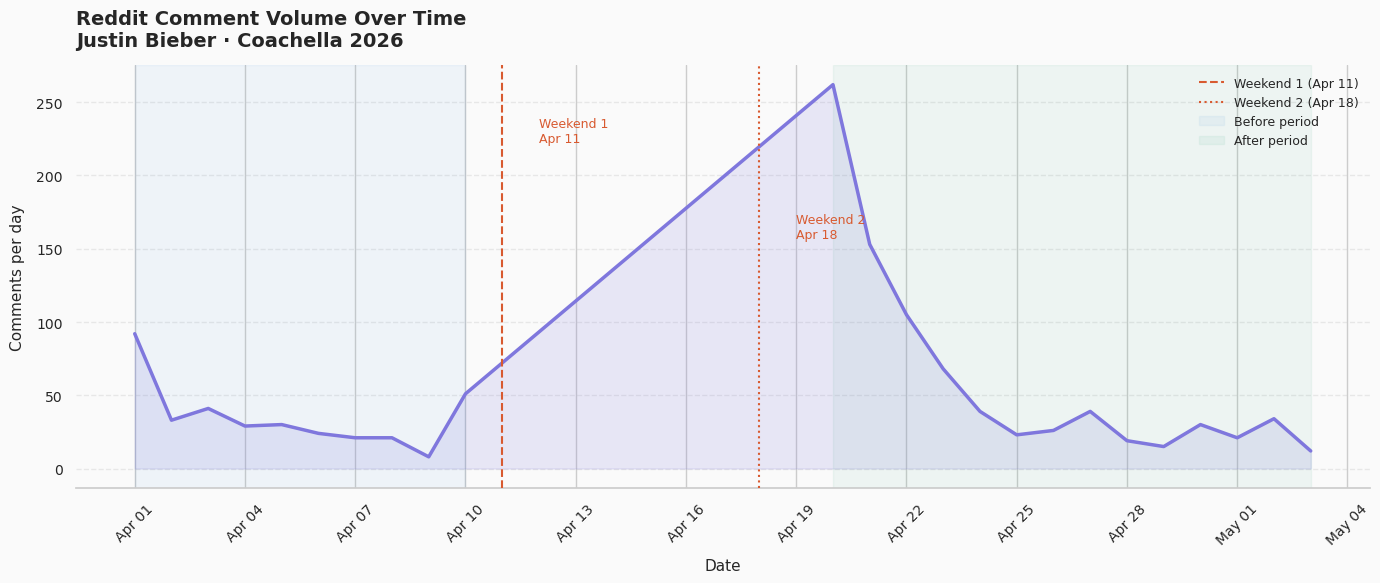

✓ Saved timeline_volume.png


In [46]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─────────────────────────────────────────
# TIMELINE / VOLUME CHART
# ─────────────────────────────────────────

df_before = pd.read_csv('reddit_llm_analysis.csv')
df_after = pd.read_csv('reddit_llm_analysis_after.csv')

# Before file is missing post_date — merge it in from the raw dated file
df_before_dates = pd.read_csv('reddit_with_dates.csv')[['Resource Id', 'post_date']]
df_before = df_before.merge(df_before_dates, on='Resource Id', how='left')

# Filter after period to exclude April 19
df_after = df_after[df_after['post_date'] >= '2026-04-20']

# Parse dates
df_before['post_date'] = pd.to_datetime(df_before['post_date'])
df_after['post_date'] = pd.to_datetime(df_after['post_date'])

# Daily comment counts
before_counts = df_before.groupby('post_date').size().reset_index(name='count')
after_counts = df_after.groupby('post_date').size().reset_index(name='count')

# Combine
all_counts = pd.concat([before_counts, after_counts]).sort_values('post_date')

# ── Plot ──
fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
ax.set_facecolor(BG)

ax.plot(all_counts['post_date'], all_counts['count'],
        color='#7F77DD', linewidth=2.5, zorder=3)
ax.fill_between(all_counts['post_date'], all_counts['count'],
                alpha=0.15, color='#7F77DD')

# Event lines
ax.axvline(pd.Timestamp('2026-04-11'), color='#D85A30', linewidth=1.5,
           linestyle='--', label='Weekend 1 (Apr 11)', zorder=4)
ax.axvline(pd.Timestamp('2026-04-18'), color='#D85A30', linewidth=1.5,
           linestyle=':', label='Weekend 2 (Apr 18)', zorder=4)

# Period shading
ax.axvspan(all_counts['post_date'].min(), pd.Timestamp('2026-04-10'),
           alpha=0.06, color='#378ADD', label='Before period')
ax.axvspan(pd.Timestamp('2026-04-20'), all_counts['post_date'].max(),
           alpha=0.06, color='#1D9E75', label='After period')

# Annotations
ax.annotate('Weekend 1\nApr 11', xy=(pd.Timestamp('2026-04-11'), ax.get_ylim()[1]),
            xytext=(pd.Timestamp('2026-04-12'), all_counts['count'].max() * 0.85),
            fontsize=9, color='#D85A30')
ax.annotate('Weekend 2\nApr 18', xy=(pd.Timestamp('2026-04-18'), ax.get_ylim()[1]),
            xytext=(pd.Timestamp('2026-04-19'), all_counts['count'].max() * 0.6),
            fontsize=9, color='#D85A30')

ax.set_title('Reddit Comment Volume Over Time\nJustin Bieber · Coachella 2026',
             fontsize=TITLE_SIZE, fontweight='bold', pad=14, loc='left')
ax.set_xlabel('Date', fontsize=LABEL_SIZE, labelpad=8)
ax.set_ylabel('Comments per day', fontsize=LABEL_SIZE, labelpad=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
ax.tick_params(axis='both', labelsize=TICK_SIZE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('timeline_volume.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Saved timeline_volume.png")